# Exploratory Data Analysis DIAObject & Object

**Goals**
1) Summarize variability over time
2) Identify candidate variable stars
3) Enable efficient filtering and prioritization
4) Support feature engineering and PCA for classification 
5) Enable cross-band behavior analysis

**Core Columns**

**DiaObject**

PSFluxChi2, PSFluxSigma, PSFluxStetsonJ, PSFluxMax, PSFluxMin, PSFluxMAD, PSFluxSkew, PSFluxLinearSlope, PSFluxNdata

**Object**

psfFlux, psfFluxErr, cModelFlux, extendedness, pixelFlags_bad, inputCount, calib_photometry_used, apFlux_flag, cModel_flag

**Summary Tables**

**DiaObject**

| Metric                      | Description                                              |
|-----------------------------|----------------------------------------------------------|
| ```Chi²```, ```Stetson J``` | Variability consistency                                  |
| ```Sigma```, ```MAD```      | Spread and robustness                                    |
| ```Skew```                  | Asymmetry of variability                                 |
| ```Max/Min/Range```         | Amplitude indicators                                     |
| ```Linear Slope```          | Temporal trends (e.g., sawtooth patterns)                |
| ```Ndata```                 | Confidence indicator for above statistics                |

**Object**

| Metric / Flag            | Description                                              |
|--------------------------|----------------------------------------------------------|
| `psfFlux`, `psfFluxErr`  | Photometric brightness and uncertainty (used for magnitudes and S/N filtering) |
| `cModelFlux`             | Model-based flux fit for extended sources (helps identify galaxies) |
| `extendedness`           | Binary star/galaxy separator: 0 = point source, 1 = extended |
| `pixelFlags_bad`         | Flag for bad pixels impacting flux measurements          |
| `inputCount`             | Number of exposures contributing to the flux measurement |
| `calib_photometry_used`  | Indicator of whether photometric calibration was applied |
| `apFlux_flag`, `cModel_flag` | Flags for aperture/model photometry reliability         |

**Tasks - Key Visualizations**
1) Stetson J vs Skew (per band): Looks for asymmetric pulses (e.g., RR Lyrae rise/fall pattern)

In [1]:
# libraries, imports, etc
import numpy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns

print('numpy version: ', numpy.__version__)
print('matplotlib version: ', matplotlib.__version__)

numpy version:  2.2.6
matplotlib version:  3.10.3


In [2]:
# TAP Service 
from lsst.rsp import get_tap_service, retrieve_query

service = get_tap_service("tap")
assert service is not None

# DiaObject

In [8]:
# Rename columns to keep band identifiers and prevent clashes
g_df = diaobjectG_df.rename(columns=lambda x: f"g_{x}" if x not in ["diaObjectId", "dec", "ra"] else x)
r_df = diaobjectR_df.rename(columns=lambda x: f"r_{x}" if x not in ["diaObjectId", "dec", "ra"] else x)
i_df = diaobjectI_df.rename(columns=lambda x: f"i_{x}" if x not in ["diaObjectId", "dec", "ra"] else x)

# Merge on diaObjectId
merged_df = g_df.merge(r_df, on="diaObjectId")
merged_df = merged_df.merge(i_df, on="diaObjectId")

# Derived features: colors and amplitudes
merged_df["g_r_color"] = merged_df["g_g_psfFluxMean"] - merged_df["r_r_psfFluxMean"]
merged_df["r_i_color"] = merged_df["r_r_psfFluxMean"] - merged_df["i_i_psfFluxMean"]

merged_df["g_amplitude"] = merged_df["g_g_psfFluxMax"] - merged_df["g_g_psfFluxMin"]
merged_df["r_amplitude"] = merged_df["r_r_psfFluxMax"] - merged_df["r_r_psfFluxMin"]
merged_df["i_amplitude"] = merged_df["i_i_psfFluxMax"] - merged_df["i_i_psfFluxMin"]

diaobject_all = merged_df

sigma = pd.concat([
    diaobject_all['g_g_psfFluxSigma'].reset_index(drop=True),
    diaobject_all['r_r_psfFluxSigma'].reset_index(drop=True),
    diaobject_all['i_i_psfFluxSigma'].reset_index(drop=True)
])

band = pd.Series(['g'] * len(diaobject_all) + ['r'] * len(diaobject_all) + ['i'] * len(diaobject_all))

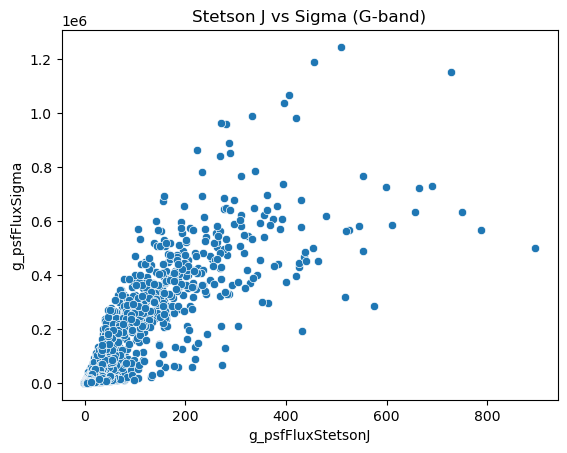

In [18]:
sns.scatterplot(data=diaobject_all, x='g_g_psfFluxStetsonJ', y='g_g_psfFluxSigma')
plt.xlabel('g_psfFluxStetsonJ'); plt.ylabel('g_psfFluxSigma')
plt.title('Stetson J vs Sigma (G-band)'); plt.show()

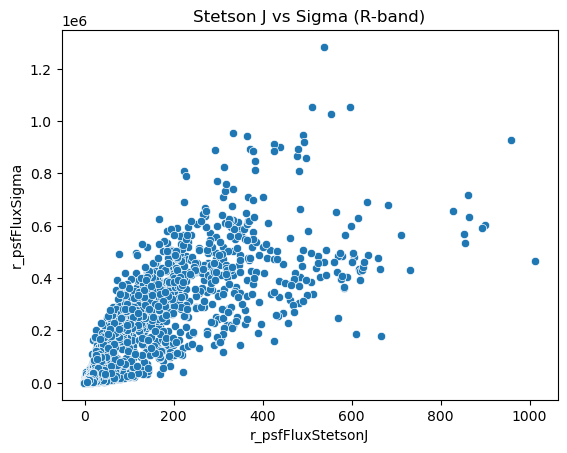

In [19]:
sns.scatterplot(data=diaobject_all, x='r_r_psfFluxStetsonJ', y='r_r_psfFluxSigma')
plt.xlabel('r_psfFluxStetsonJ'); plt.ylabel('r_psfFluxSigma')
plt.title('Stetson J vs Sigma (R-band)'); plt.show()

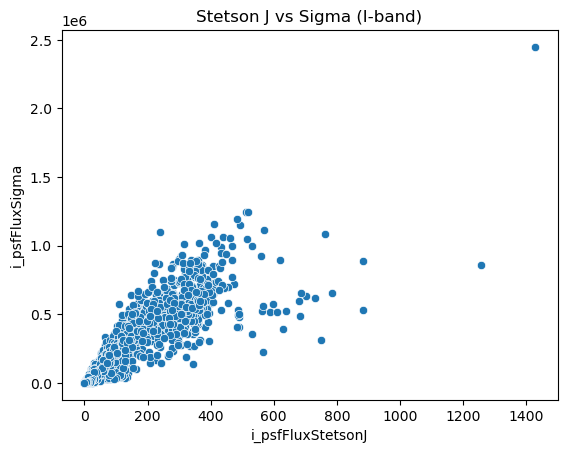

In [12]:
sns.scatterplot(data=diaobject_all, x='i_i_psfFluxStetsonJ', y='i_i_psfFluxSigma')
plt.xlabel('i_psfFluxStetsonJ'); plt.ylabel('i_psfFluxSigma')
plt.title('Stetson J vs Sigma (I-band)'); plt.show()

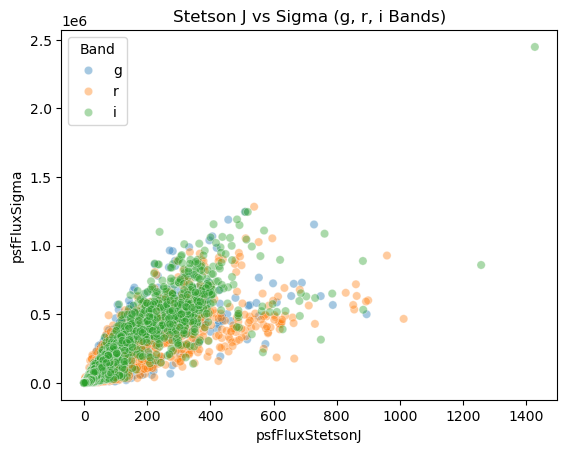

In [29]:
stetsonj = pd.concat([
    diaobject_all['g_g_psfFluxStetsonJ'].reset_index(drop=True),
    diaobject_all['r_r_psfFluxStetsonJ'].reset_index(drop=True),
    diaobject_all['i_i_psfFluxStetsonJ'].reset_index(drop=True)
])

stetsonj_sigma_long = pd.DataFrame({
    'StetsonJ': stetsonj.values,
    'Sigma': sigma.values,
    'Band': band.values
})

sns.scatterplot(data=stetsonj_sigma_long, x='StetsonJ', y='Sigma', hue='Band', alpha=0.4)
plt.title('Stetson J vs Sigma (g, r, i Bands)')
plt.xlabel('psfFluxStetsonJ')
plt.ylabel('psfFluxSigma')
plt.legend(title='Band')
plt.show()

2) MAD vs Std Dev Histogram(per band): Compares outlier-robust and sensitive metrics

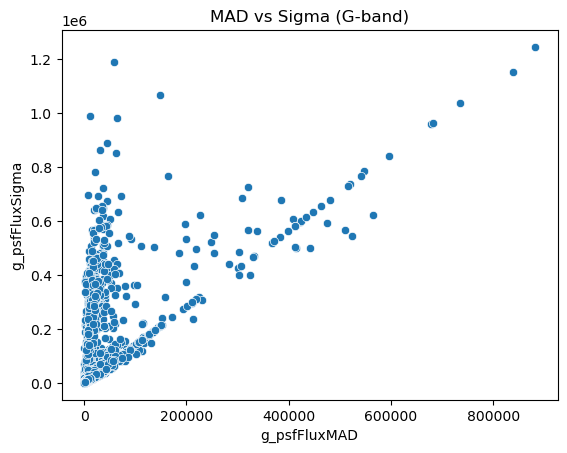

In [20]:
sns.scatterplot(data=diaobject_all, x='g_g_psfFluxMAD', y='g_g_psfFluxSigma')
plt.xlabel('g_psfFluxMAD'); plt.ylabel('g_psfFluxSigma')
plt.title('MAD vs Sigma (G-band)'); plt.show()

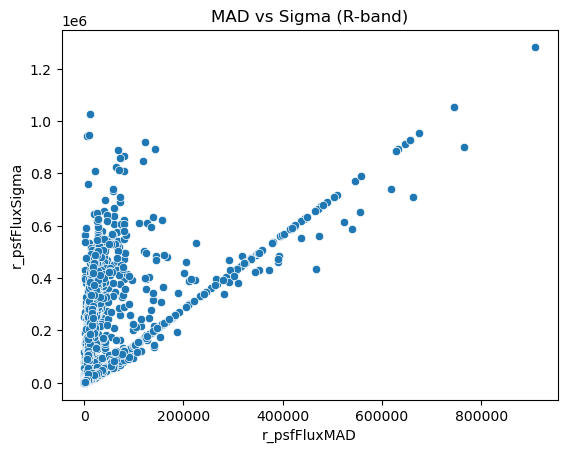

In [21]:
sns.scatterplot(data=diaobject_all, x='r_r_psfFluxMAD', y='r_r_psfFluxSigma')
plt.xlabel('r_psfFluxMAD'); plt.ylabel('r_psfFluxSigma')
plt.title('MAD vs Sigma (R-band)'); plt.show()

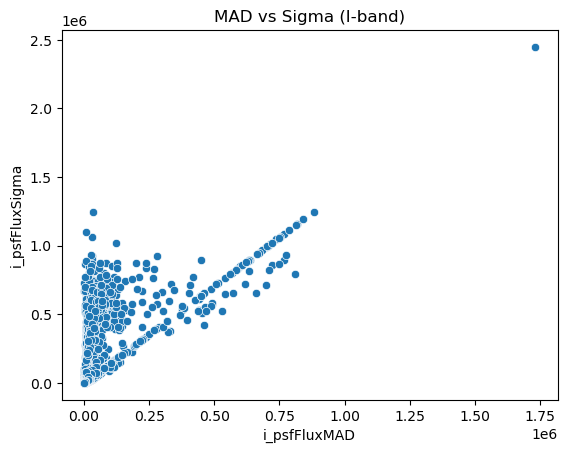

In [22]:
sns.scatterplot(data=diaobject_all, x='i_i_psfFluxMAD', y='i_i_psfFluxSigma')
plt.xlabel('i_psfFluxMAD'); plt.ylabel('i_psfFluxSigma')
plt.title('MAD vs Sigma (I-band)'); plt.show()

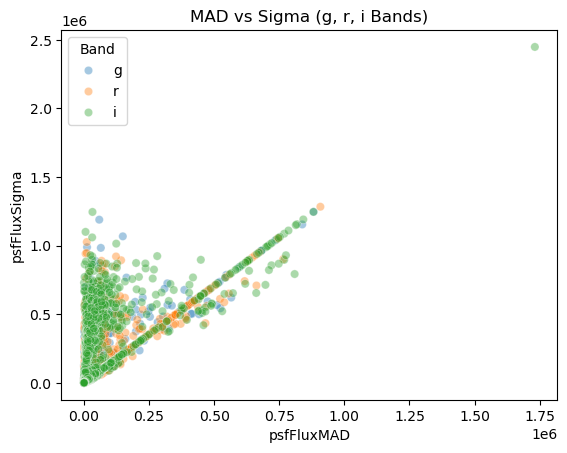

In [23]:
mad = pd.concat([
    diaobject_all['g_g_psfFluxMAD'].reset_index(drop=True),
    diaobject_all['r_r_psfFluxMAD'].reset_index(drop=True),
    diaobject_all['i_i_psfFluxMAD'].reset_index(drop=True)
])

mad_sigma_long = pd.DataFrame({
    'MAD': mad.values,
    'Sigma': sigma.values,
    'Band': band.values
})

sns.scatterplot(data=mad_sigma_long, x='MAD', y='Sigma', hue='Band', alpha=0.4)
plt.title('MAD vs Sigma (g, r, i Bands)')
plt.xlabel('psfFluxMAD')
plt.ylabel('psfFluxSigma')
plt.legend(title='Band')
plt.show()

3) Amplitude vs Sigma Scatterplot (per band): Finds large-amplitude stars

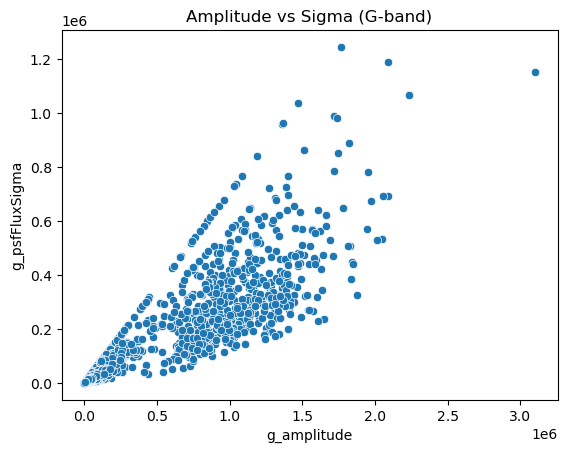

In [24]:
sns.scatterplot(data=diaobject_all, x='g_amplitude', y='g_g_psfFluxSigma')
plt.xlabel('g_amplitude'); plt.ylabel('g_psfFluxSigma')
plt.title('Amplitude vs Sigma (G-band)'); plt.show()

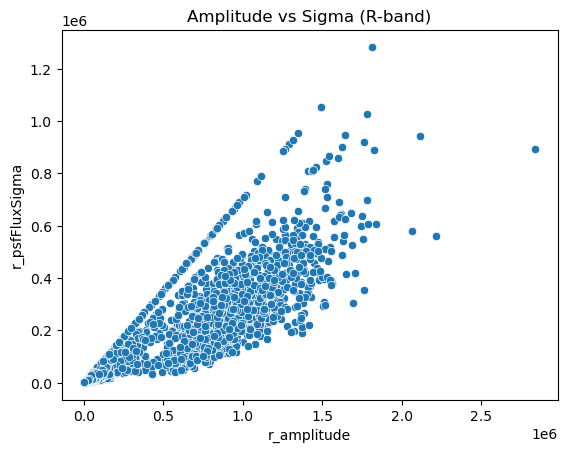

In [25]:
sns.scatterplot(data=diaobject_all, x='r_amplitude', y='r_r_psfFluxSigma')
plt.xlabel('r_amplitude'); plt.ylabel('r_psfFluxSigma')
plt.title('Amplitude vs Sigma (R-band)'); plt.show()

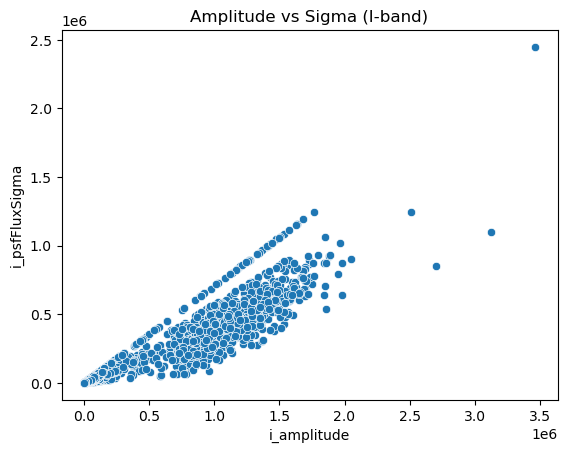

In [26]:
sns.scatterplot(data=diaobject_all, x='i_amplitude', y='i_i_psfFluxSigma')
plt.xlabel('i_amplitude'); plt.ylabel('i_psfFluxSigma')
plt.title('Amplitude vs Sigma (I-band)'); plt.show()

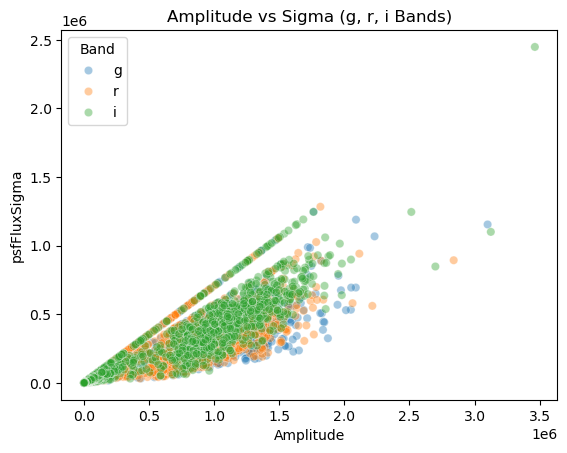

In [27]:
amplitude = pd.concat([
    diaobject_all['g_amplitude'].reset_index(drop=True),
    diaobject_all['r_amplitude'].reset_index(drop=True),
    diaobject_all['i_amplitude'].reset_index(drop=True)
])

amplitude_sigma_long = pd.DataFrame({
    'Amplitude': amplitude.values,
    'Sigma': sigma.values,
    'Band': band.values
})

sns.scatterplot(data=amplitude_sigma_long, x='Amplitude', y='Sigma', hue='Band', alpha=0.4)
plt.title('Amplitude vs Sigma (g, r, i Bands)')
plt.xlabel('Amplitude')
plt.ylabel('psfFluxSigma')
plt.legend(title='Band')
plt.show()


4) Stetson J vs Amplitude(per band): Flags high-priority candidates

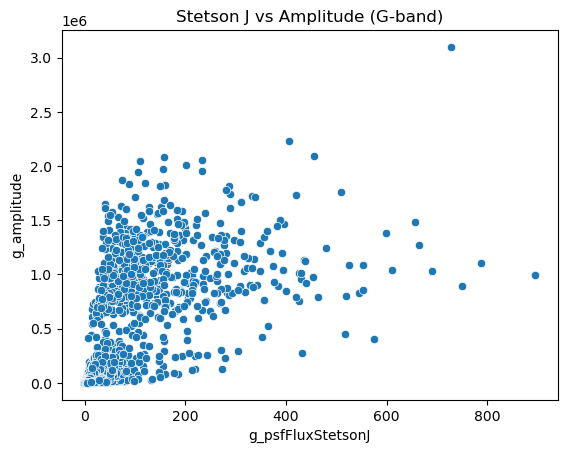

In [31]:
sns.scatterplot(data=diaobject_all, x='g_g_psfFluxStetsonJ', y='g_amplitude')
plt.xlabel('g_psfFluxStetsonJ'); plt.ylabel('g_amplitude')
plt.title('Stetson J vs Amplitude (G-band)'); plt.show()

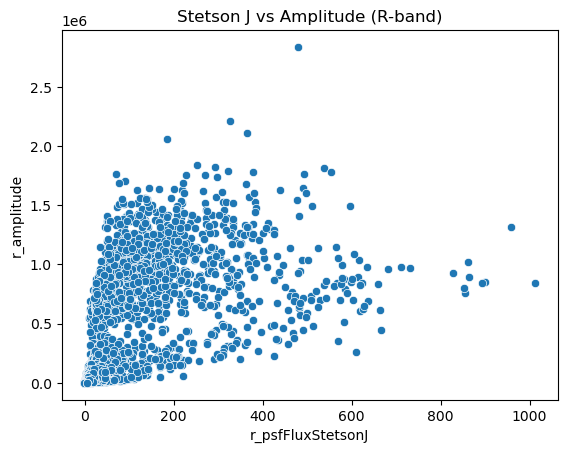

In [32]:
sns.scatterplot(data=diaobject_all, x='r_r_psfFluxStetsonJ', y='r_amplitude')
plt.xlabel('r_psfFluxStetsonJ'); plt.ylabel('r_amplitude')
plt.title('Stetson J vs Amplitude (R-band)'); plt.show()

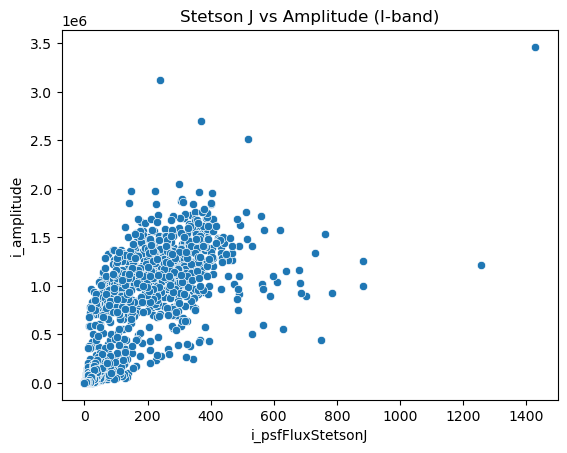

In [33]:
sns.scatterplot(data=diaobject_all, x='i_i_psfFluxStetsonJ', y='i_amplitude')
plt.xlabel('i_psfFluxStetsonJ'); plt.ylabel('i_amplitude')
plt.title('Stetson J vs Amplitude (I-band)'); plt.show()

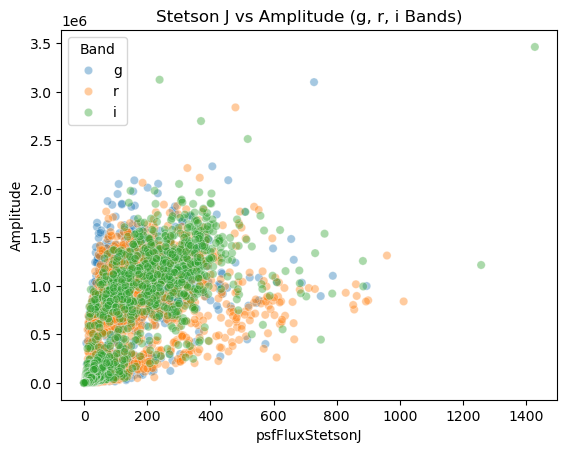

In [34]:
stetsonj_amplitude_long = pd.DataFrame({
    'StetsonJ': stetsonj.values,
    'Amplitude': amplitude.values,
    'Band': band.values
})

sns.scatterplot(data=stetsonj_amplitude_long, x='StetsonJ', y='Amplitude', hue='Band', alpha=0.4)
plt.title('Stetson J vs Amplitude (g, r, i Bands)')
plt.xlabel('psfFluxStetsonJ')
plt.ylabel('Amplitude')
plt.legend(title='Band')
plt.show()

# Object

 5) Flag Distributions

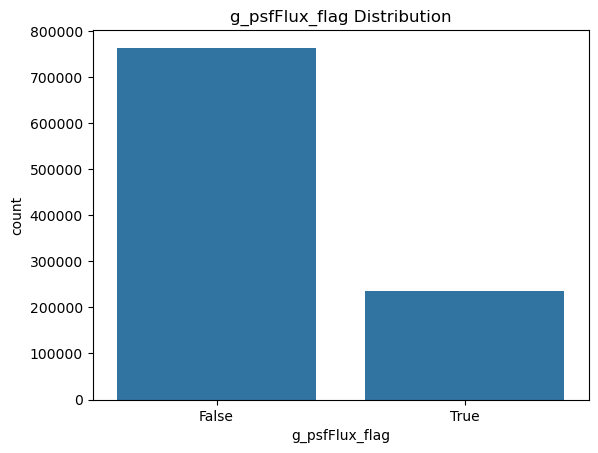

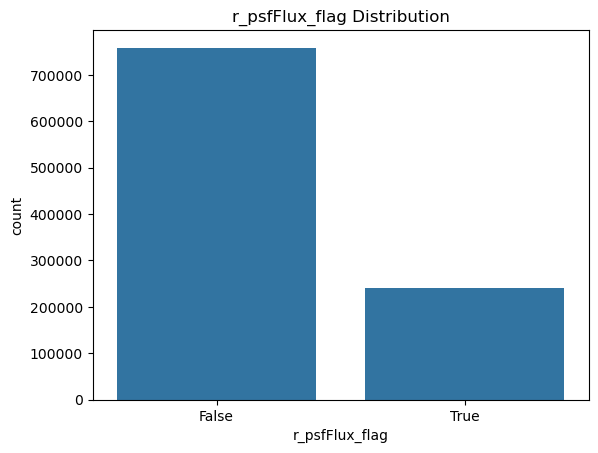

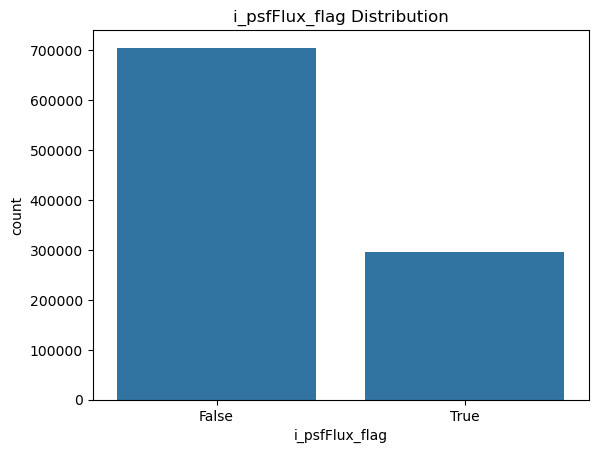

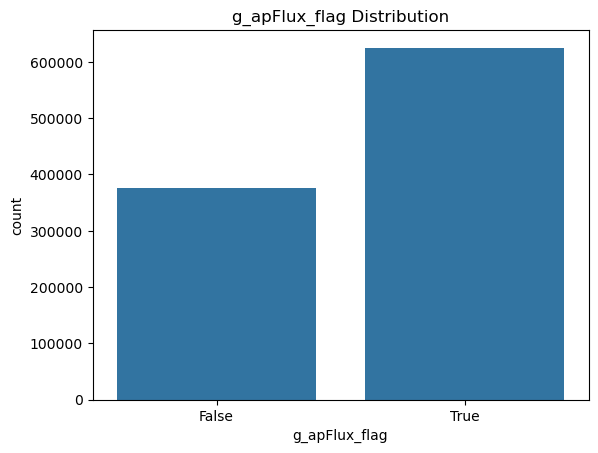

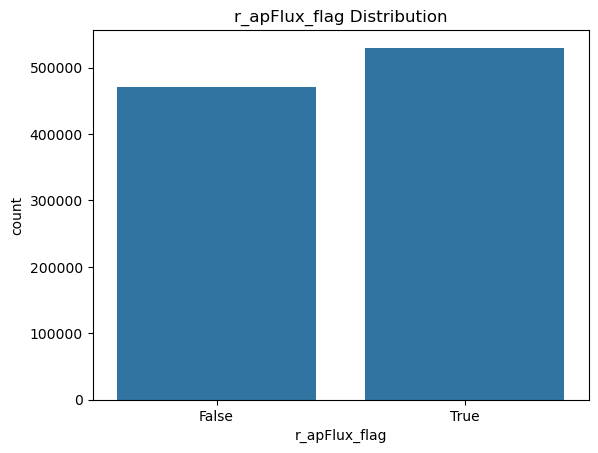

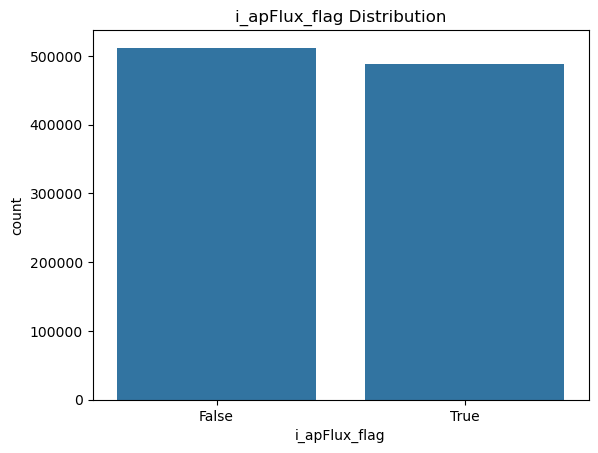

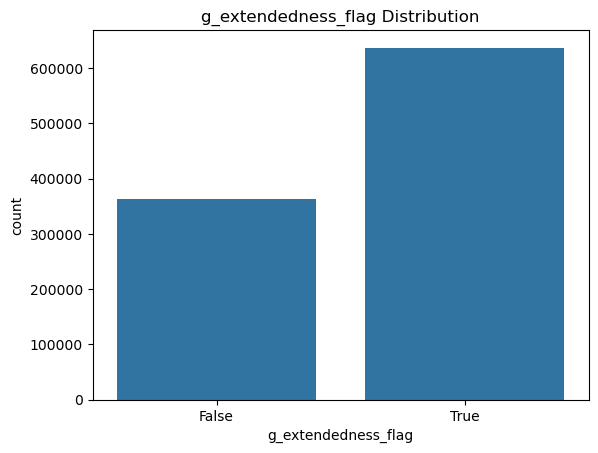

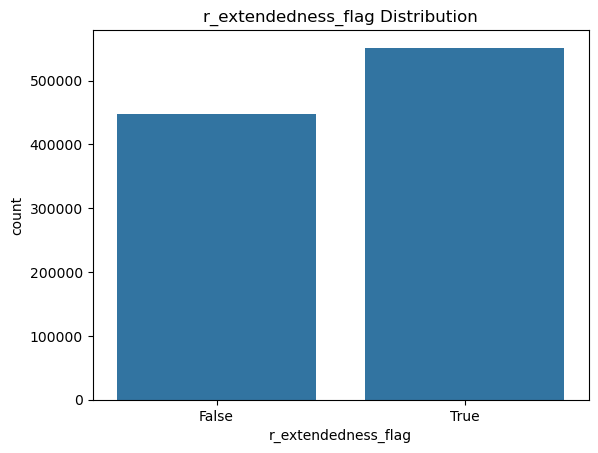

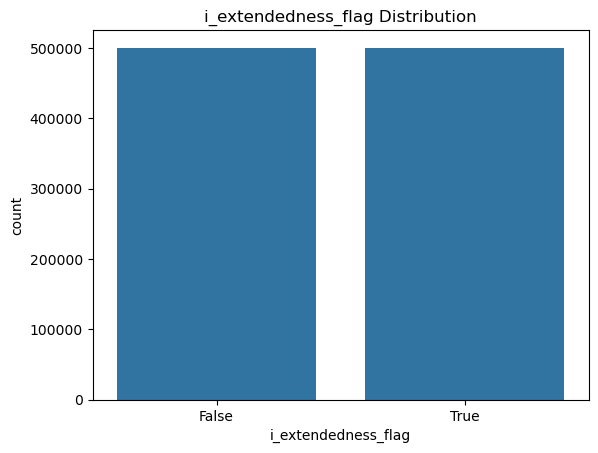

In [35]:
flag_cols = ['g_psfFlux_flag', 'r_psfFlux_flag', 'i_psfFlux_flag',
             'g_apFlux_flag', 'r_apFlux_flag', 'i_apFlux_flag',
             'g_extendedness_flag', 'r_extendedness_flag', 'i_extendedness_flag']

for col in flag_cols:
    sns.countplot(data=object_df, x=col)
    plt.title(f'{col} Distribution')
    plt.show()

6) Flux vs Flux Error

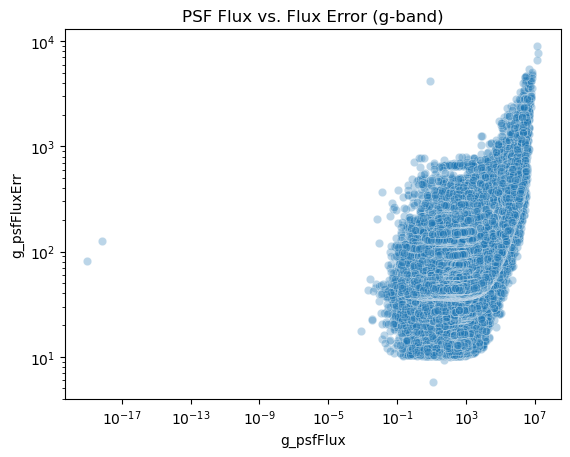

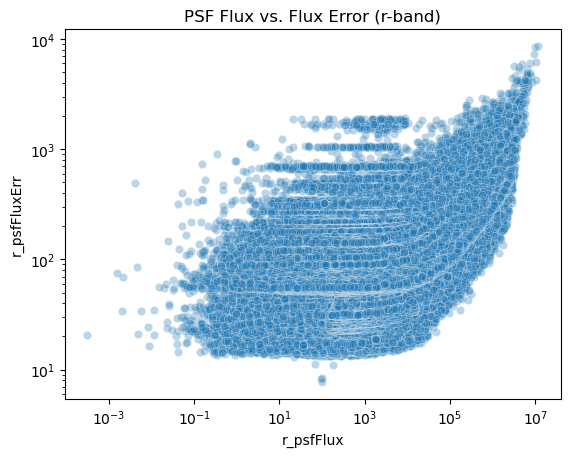

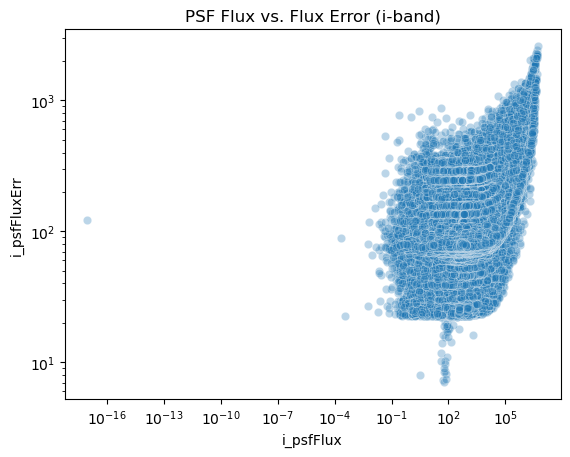

In [39]:
for band in ['g', 'r', 'i']:
    sns.scatterplot(
        data=object_df,
        x=f'{band}_psfFlux',
        y=f'{band}_psfFluxErr',
        alpha=0.3
    )
    plt.xlabel(f'{band}_psfFlux')
    plt.ylabel(f'{band}_psfFluxErr')
    plt.title(f'PSF Flux vs. Flux Error ({band}-band)')
    plt.xscale('log'); plt.yscale('log')
    plt.show()

7) Extendedness vs PSF Flux

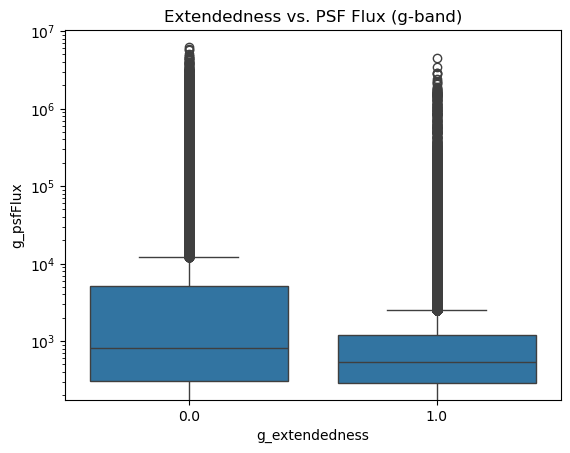

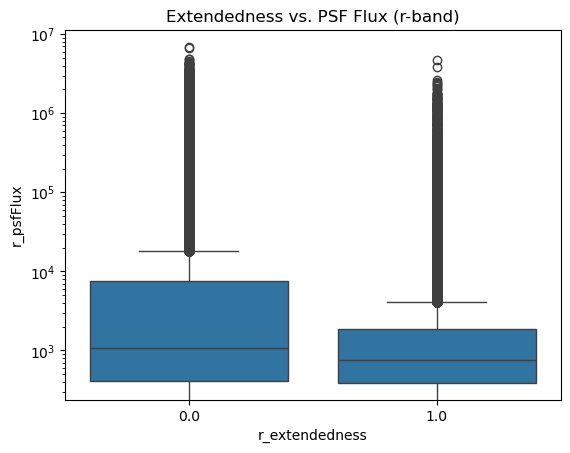

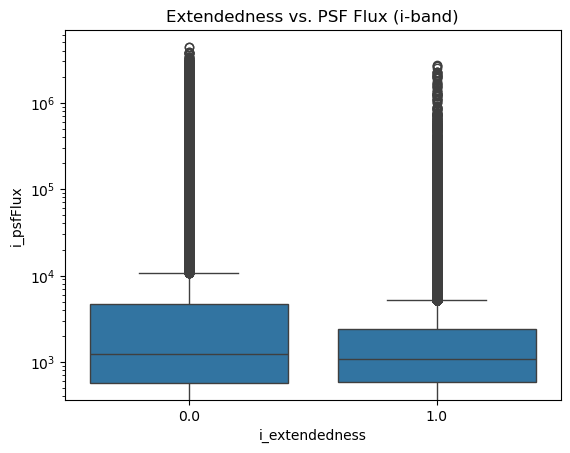

In [40]:
for band in ['g', 'r', 'i']:
    sns.boxplot(
        data=object_df,
        x=f'{band}_extendedness',
        y=f'{band}_psfFlux'
    )
    plt.yscale('log')
    plt.title(f'Extendedness vs. PSF Flux ({band}-band)')
    plt.show()

8) CModel vs PSF Flux

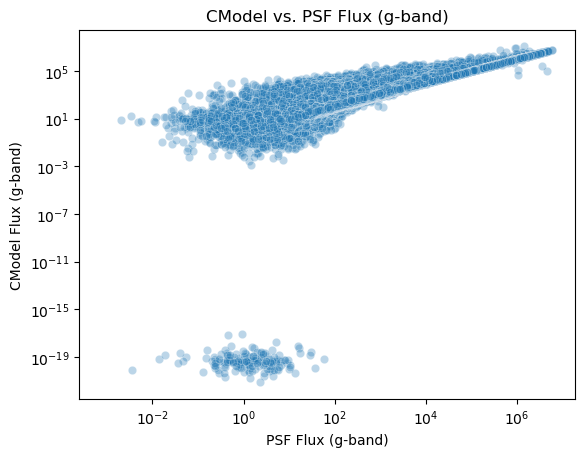

In [41]:
sns.scatterplot(
    data=object_df,
    x='g_psfFlux',
    y='g_cModelFlux',
    alpha=0.3
)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('PSF Flux (g-band)')
plt.ylabel('CModel Flux (g-band)')
plt.title('CModel vs. PSF Flux (g-band)')
plt.show()


In [ ]:
9) BD Chi2 vs Flux Error

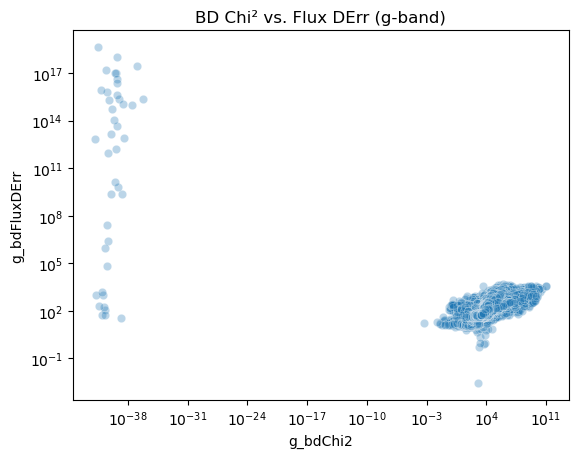

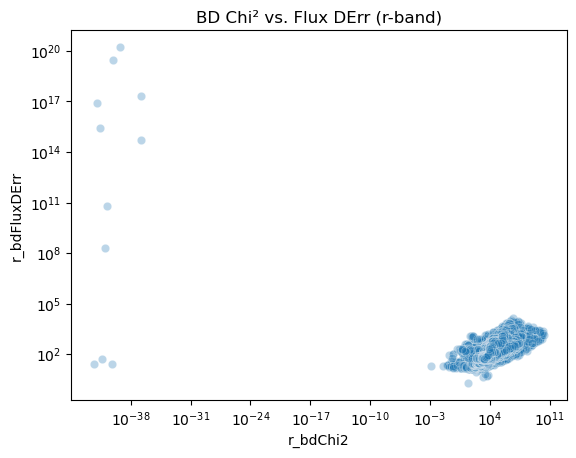

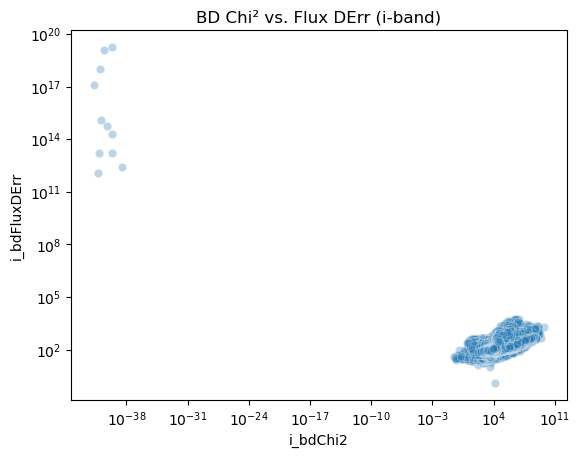

In [42]:
for band in ['g', 'r', 'i']:
    sns.scatterplot(
        data=object_df,
        x=f'{band}_bdChi2',
        y=f'{band}_bdFluxDErr',
        alpha=0.3
    )
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel(f'{band}_bdChi2')
    plt.ylabel(f'{band}_bdFluxDErr')
    plt.title(f'BD Chi² vs. Flux DErr ({band}-band)')
    plt.show()

10) Color Magnitude Diagram

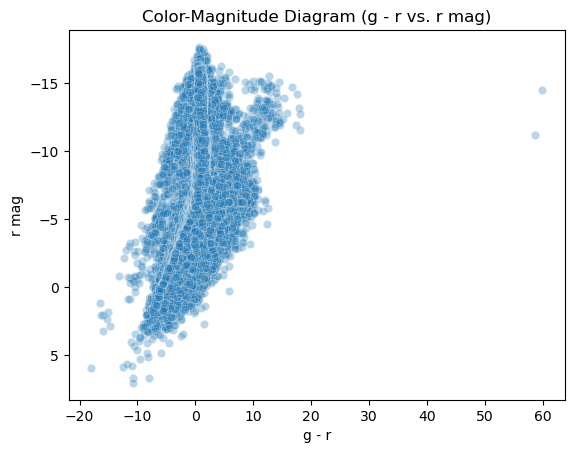

In [43]:
import numpy as np

# Convert flux to magnitude safely
def flux_to_mag(flux):
    return -2.5 * np.log10(np.where(flux > 0, flux, np.nan))

object_df['g_mag'] = flux_to_mag(object_df['g_psfFlux'])
object_df['r_mag'] = flux_to_mag(object_df['r_psfFlux'])
object_df['i_mag'] = flux_to_mag(object_df['i_psfFlux'])

object_df['g_r_color'] = object_df['g_mag'] - object_df['r_mag']
object_df['r_i_color'] = object_df['r_mag'] - object_df['i_mag']

# g - r color-magnitude diagram
sns.scatterplot(
    data=object_df,
    x='g_r_color',
    y='r_mag',
    alpha=0.3
)
plt.gca().invert_yaxis()
plt.xlabel('g - r')
plt.ylabel('r mag')
plt.title('Color-Magnitude Diagram (g - r vs. r mag)')
plt.show()


# Combined Summary of Color, Morphology, and Variability Analysis  
**Rubin DP1 — DiaObject + Object Tables**

This analysis integrates information from the `DiaObject` table (variability metrics like `psfFluxSigma`, `StetsonJ`, MAD) with the `Object` table (fluxes, shapes, calibration flags, extendedness) across the **g, r, and i bands**. The goal is to understand and classify variable sources, especially **RR Lyrae**, **Cepheids**, and **Miras**, based on flux behavior, variability, and color indices.

---

## Key Findings

### Cross-band Variability Patterns (DiaObject)
- **g vs r/i `psfFluxSigma`**:
  - **RR Lyrae** show **higher variability in g-band**, appearing **above the 1:1 line**.
  - **Cepheids** and **Miras** often show stronger variability in **r or i**, appearing **below the line**.
- **r vs i** variability:
  - **Miras** have stronger i-band variation.
  - **Cepheids** tend to have peak variability in the r-band.

### Color vs Variability Trends
- **RR Lyrae**:
  - Blue colors (`g - r < 0`, `r - i < 0`)
  - High g-band variability (`psfFluxSigma_g`)
- **Miras**:
  - Very red (`r - i > 0.5`)
  - High amplitude in i-band
- **Cepheids**:
  - Intermediate colors and moderate variability, often strongest in r

### Variability Distribution
- Histograms of `psfFluxSigma` show:
  - Most sources are low-variability
  - A **long-tailed distribution**, indicating rare but highly variable stars
  - Thresholding on the tail can help **identify candidate variables**

---

## Object Table Insights (Morphology, Flux, Color)

### BD Chi² vs. Flux Error
- Most sources cluster around **reasonable chi² and error values**
- A distinct group with **extremely low chi² values (∼1e-38)** likely reflects **invalid entries or failed model fits**

### CModel vs. PSF Flux
- Two regimes observed:
  - **Tight diagonal cluster**: CModel ≈ PSF for **point sources**
  - **Flat floor at ≈1e-19**: indicative of **bad or flagged CModel fluxes**
- Useful for identifying **faint or problematic measurements**

### Extendedness vs. PSF Flux
- Extended objects (`extendedness = 1`) generally have **lower median PSF flux**, but overlap with point sources is large
- Alone, extendedness is not a clean separator; combine with **color or flux ratio (e.g. PSF/CModel)**

### PSF Flux vs. Error
- Clear positive correlation: flux increases → error increases
- **Binning/ridging patterns** observed at low fluxes, likely due to quantized flux calibration
- Suggests a **photometric floor** and limitations on S/N at faint end

### Color-Magnitude Diagram (g - r vs. r mag)
- Main stellar population follows a **clear trend**
- Outliers with extreme colors (`g - r > 10`, `g - r < -10`) and magnitudes are likely **flux artifacts** due to non-positive flux values or log transform issues

---

## Summary Table: Variable Star Types

| Type        | Color Index           | Variability Profile           | Peak Band |
|-------------|------------------------|-------------------------------|-----------|
| **RR Lyrae**  | Blue (`g - r < 0`)      | High variability in g         | **g-band** |
| **Cepheids**  | Moderate (`0 < g - r < 1`) | r > i variability           | **r-band** |
| **Miras**     | Red (`r - i > 0.5`)     | Strong i-band variability     | **i-band** |

---

## Interpretation

- **RR Lyrae** are short-period pulsators with strong blue-band variability and blue colors — excellent distance indicators in time-domain studies.
- **Cepheids** show symmetric light curves with r-dominant variability and intermediate colors — useful for cosmic distance ladders.
- **Miras** are long-period red giants, often extremely red and variable in the i-band — useful for studying late stellar evolution.